# UR10 cobot-cell scene builder (Stage 2, Scene 1 -- grounded)

Self-contained, portable generator for the device-free worker
**presence + coarse count + safety-zone** task in a **fenceless
human-robot collaborative cell**, grounded in real specs:

- **Robot:** UR10 cobot -- reach 1.3 m (Universal Robots spec).
- **Safety zones:** ISO/TS 15066 speed-and-separation monitoring --
  concentric rings from the robot base: **red = stop**, **yellow =
  reduced speed**, **green = full speed**. This is the 'coarse zone'
  label, and it is a real standards-based safety classification.
- **Cell:** a large (~12 x 10 m) fenceless collaborative bay so most
  of the floor is green (safe); the CNC, controller cabinet, operator
  bench and pallet give realistic metal clutter.
- **Radios:** transmitters are the factory's EXISTING networked
  equipment; the AP is a ceiling WiFi AP. Nothing new is installed.

**Honest framing** (keep in the write-up): a SIMULATION capability
study (does the info live in the CSI?), NOT a product and NOT a
certified interlock (real cells use light curtains / laser scanners).
No camera comparison -- the motivation for device-free WiFi is cited,
not staged.

**How to use**
1. Edit **PARAMETERS**, 2. run **BUILD**, 3. run **PREVIEW**.
Pure stdlib + matplotlib (no Sionna) -> runs on laptop / lab / Colab.
Single source of truth for this scene. `robot_cell` (the earlier
hand-made cell) is kept separately as a fallback -- do not delete it.

Emits: `hrc_ur10_cell/hrc_ur10_cell_robot.xml` (robot present),
`..._norobot.xml` (robot removed -- coverage reference),
`hrc_ur10_cell.json` (geometry + safety-zone contract for data-gen).

Units: metres; +z up; floor z=0; bay centred at origin.

In [1]:
# ================================================================
# PARAMETERS  -- edit these, then run BUILD + PREVIEW
# ================================================================

SCENE_NAME = "hrc_ur10_cell"

# Fenceless collaborative bay (large -> most of the floor is green)
ROOM_X, ROOM_Y, ROOM_Z = 12.0, 10.0, 3.5
WALL_T = 0.15

MAT_WALL    = "concrete"      # floor + 4 walls
MAT_CEILING = "metal"         # metal roof deck
MAT_METAL   = "metal"         # robot + equipment (metal-heavy, realistic)

# Objects: name, (sx, sy, sz), (cx, cy, cz), material, removable_for_ref
# The UR10 = pedestal + shoulder + an arm reaching north into the CNC
# (a fixed static pose; snapshot-only). removable_for_ref objects are
# dropped from the _norobot.xml variant (coverage reference).
ROBOT = [
    ("Robot_base",     (0.35, 0.35, 0.90), ( 0.00,  0.00, 0.45), MAT_METAL, True),
    ("Robot_shoulder", (0.30, 0.30, 0.40), ( 0.00,  0.00, 1.10), MAT_METAL, True),
    ("Robot_arm",      (0.30, 0.90, 0.30), ( 0.00,  0.65, 1.25), MAT_METAL, True),
]
EQUIPMENT = [
    ("CNC_machine",    (1.60, 1.00, 1.60), ( 0.00,  1.90, 0.80), MAT_METAL, False),
    ("Cabinet",        (0.50, 0.60, 1.80), (-2.50, -0.50, 0.90), MAT_METAL, False),
    ("Operator_bench", (1.20, 0.50, 0.90), ( 0.00, -2.20, 0.45), MAT_METAL, False),
    ("Pallet",         (0.80, 0.80, 0.50), ( 2.20,  0.30, 0.25), MAT_METAL, False),
]
OBJECTS = ROBOT + EQUIPMENT

# Safety zones = ISO/TS 15066 speed-separation rings from the robot base.
# A worker's distance to the base -> label: red (<= red_r) / yellow
# (<= yellow_r) / green (beyond). red ~ reach(1.3) + buffer.
SAFETY_ZONES = {"type": "rings",
                "center": [0.0, 0.0],
                "red_radius": 1.6,      # robot stops
                "yellow_radius": 2.8,   # reduced speed (green = beyond)
                "labels": ["green", "yellow", "red"],
                "standard": "ISO/TS 15066 speed-and-separation monitoring"}

# Worker placement region: floor inset from walls, minus object footprints
# (+ clearance). NOTE for data-gen: the bay is mostly green, so BIAS
# worker sampling toward the robot base to balance red/yellow/green.
WORKER_INSET = 0.5
OBJ_CLEARANCE = 0.3

# TX = existing networked equipment (antenna just outside each host).
# AP = ceiling WiFi AP. Not written into the XML; live in the sidecar.
SUGGESTED_TX = [
    ("iot_cabinet", (-2.50, -0.50, 1.85)),   # on the controller cabinet
    ("iot_cnc",     ( 0.00,  1.40, 1.60)),   # on the CNC (front face)
    ("iot_bench",   ( 0.00, -2.20, 1.00)),   # networked tool on operator bench
    ("iot_wall_e",  ( 5.85,  0.00, 2.20)),   # wall-mounted networked device
]
SUGGESTED_AP = {"pos": (1.50, -1.20, 3.40), "n_ant": 4}   # ceiling AP

print("parameters loaded:", SCENE_NAME,
      f"| bay {ROOM_X}x{ROOM_Y}x{ROOM_Z} m | {len(OBJECTS)} objects")

parameters loaded: hrc_ur10_cell | bay 12.0x10.0x3.5 m | 7 objects


In [2]:
# ================================================================
# GENERATOR  -- Mitsuba-3 XML + sidecar. No need to edit.
# ================================================================
import json
from pathlib import Path


def room_boxes():
    hx, hy, hz = ROOM_X / 2, ROOM_Y / 2, ROOM_Z / 2
    t = WALL_T
    return [
        ("Floor",   (ROOM_X, ROOM_Y, t), (0.0, 0.0, -t / 2),         MAT_WALL),
        ("Ceiling", (ROOM_X, ROOM_Y, t), (0.0, 0.0, ROOM_Z + t / 2), MAT_CEILING),
        ("Wall_N",  (ROOM_X, t, ROOM_Z), (0.0,  hy + t / 2, hz),     MAT_WALL),
        ("Wall_S",  (ROOM_X, t, ROOM_Z), (0.0, -hy - t / 2, hz),     MAT_WALL),
        ("Wall_E",  (t, ROOM_Y, ROOM_Z), ( hx + t / 2, 0.0, hz),     MAT_WALL),
        ("Wall_W",  (t, ROOM_Y, ROOM_Z), (-hx - t / 2, 0.0, hz),     MAT_WALL),
    ]


def bsdf_xml(mat_type):
    return (f'    <bsdf type="itu-radio-material" id="mat-{mat_type}">\n'
            f'        <string name="type" value="{mat_type}"/>\n'
            f'    </bsdf>\n')


def cube_xml(name, size, center, mat_type):
    # Mitsuba `cube` is the unit cube [-1,1]^3 (half-extent 1):
    # scale by half-extents, then translate to the centre.
    hx, hy, hz = size[0] / 2, size[1] / 2, size[2] / 2
    cx, cy, cz = center
    return (f'    <shape type="cube" id="{name}">\n'
            f'        <transform name="to_world">\n'
            f'            <scale x="{hx:.4f}" y="{hy:.4f}" z="{hz:.4f}"/>\n'
            f'            <translate x="{cx:.4f}" y="{cy:.4f}" z="{cz:.4f}"/>\n'
            f'        </transform>\n'
            f'        <ref id="mat-{mat_type}"/>\n'
            f'    </shape>\n')


def build_scene_xml(include_robot):
    boxes = [(n, s, c, m) for (n, s, c, m) in room_boxes()]
    for (n, s, c, m, removable) in OBJECTS:
        if removable and not include_robot:
            continue
        boxes.append((n, s, c, m))
    used = sorted({mat for (_, _, _, mat) in boxes})
    parts = ['<scene version="3.0.0">\n', '    <integrator type="path"/>\n\n']
    parts += [bsdf_xml(m) for m in used]
    parts.append('\n')
    parts += [cube_xml(n, s, c, m) for (n, s, c, m) in boxes]
    parts.append('</scene>\n')
    return "".join(parts)


def _footprint(size, center, clearance):
    hx, hy = size[0] / 2 + clearance, size[1] / 2 + clearance
    cx, cy = center[0], center[1]
    return {"x_min": cx - hx, "x_max": cx + hx,
            "y_min": cy - hy, "y_max": cy + hy}


def build_sidecar():
    exclusions = [{"name": n, **_footprint(s, c, OBJ_CLEARANCE)}
                  for (n, s, c, m, _r) in OBJECTS]
    return {
        "scene_name": SCENE_NAME,
        "scenario": "fenceless human-robot collaborative cell (UR10)",
        "robot": {"model": "UR10", "reach_m": 1.3},
        "units": "metres; +z up; floor z=0; bay centred at origin",
        "room": {"x": ROOM_X, "y": ROOM_Y, "z": ROOM_Z, "wall_t": WALL_T},
        "materials": {"wall": MAT_WALL, "ceiling": MAT_CEILING,
                      "equipment": MAT_METAL},
        "objects": [{"name": n, "size": list(s), "center": list(c),
                     "material": m, "removable_for_ref": r}
                    for (n, s, c, m, r) in OBJECTS],
        "robot_objects": [n for (n, _, _, _, r) in OBJECTS if r],
        "safety_zones": SAFETY_ZONES,
        "worker_region": {
            "type": "rect_with_exclusions",
            "x_min": -ROOM_X / 2 + WORKER_INSET,
            "x_max":  ROOM_X / 2 - WORKER_INSET,
            "y_min": -ROOM_Y / 2 + WORKER_INSET,
            "y_max":  ROOM_Y / 2 - WORKER_INSET,
            "exclusions": exclusions,
            "sampling_hint": "bias toward robot base to balance red/yellow/green",
        },
        "suggested_tx": [{"name": n, "pos": list(p), "host": n.replace('iot_', '')}
                         for (n, p) in SUGGESTED_TX],
        "suggested_ap": {"pos": list(SUGGESTED_AP["pos"]),
                         "n_ant": SUGGESTED_AP["n_ant"], "mount": "ceiling"},
        "variants": {"robot": f"{SCENE_NAME}_robot.xml",
                     "norobot": f"{SCENE_NAME}_norobot.xml"},
    }

print("generator ready")

generator ready


In [3]:
# ================================================================
# BUILD  -- write the two XMLs + JSON sidecar
# ================================================================
try:
    base_dir = Path(__file__).parent  # not defined in notebooks
except NameError:
    base_dir = Path.cwd()

out_dir = base_dir / SCENE_NAME
out_dir.mkdir(parents=True, exist_ok=True)

robot_path = out_dir / f"{SCENE_NAME}_robot.xml"
noro_path = out_dir / f"{SCENE_NAME}_norobot.xml"
json_path = out_dir / f"{SCENE_NAME}.json"

robot_path.write_text(build_scene_xml(include_robot=True), encoding="utf-8")
noro_path.write_text(build_scene_xml(include_robot=False), encoding="utf-8")
json_path.write_text(json.dumps(build_sidecar(), indent=2), encoding="utf-8")

print("wrote:")
print(" ", robot_path)
print(" ", noro_path)
print(" ", json_path)
print(f"  robot   : 6 shell + {len(ROBOT)} robot + {len(EQUIPMENT)} equipment")
print(f"  norobot : 6 shell + {len(EQUIPMENT)} equipment (robot removed)")

wrote:
  d:\91\Post Graduate\Project selection\Wireless Sensing\workspace\stage2\scenes\hrc_ur10_cell\hrc_ur10_cell_robot.xml
  d:\91\Post Graduate\Project selection\Wireless Sensing\workspace\stage2\scenes\hrc_ur10_cell\hrc_ur10_cell_norobot.xml
  d:\91\Post Graduate\Project selection\Wireless Sensing\workspace\stage2\scenes\hrc_ur10_cell\hrc_ur10_cell.json
  robot   : 6 shell + 3 robot + 4 equipment
  norobot : 6 shell + 4 equipment (robot removed)


## Preview (top-down)

Metal objects grey (robot hatched = removed in the no-robot reference),
ISO/TS 15066 zones as rings from the robot base (red stop / yellow
reduced / green full-speed), faint red boxes = excluded footprints,
dashed rectangle = legal worker region, triangles = equipment-mounted
TXs, square = ceiling AP.

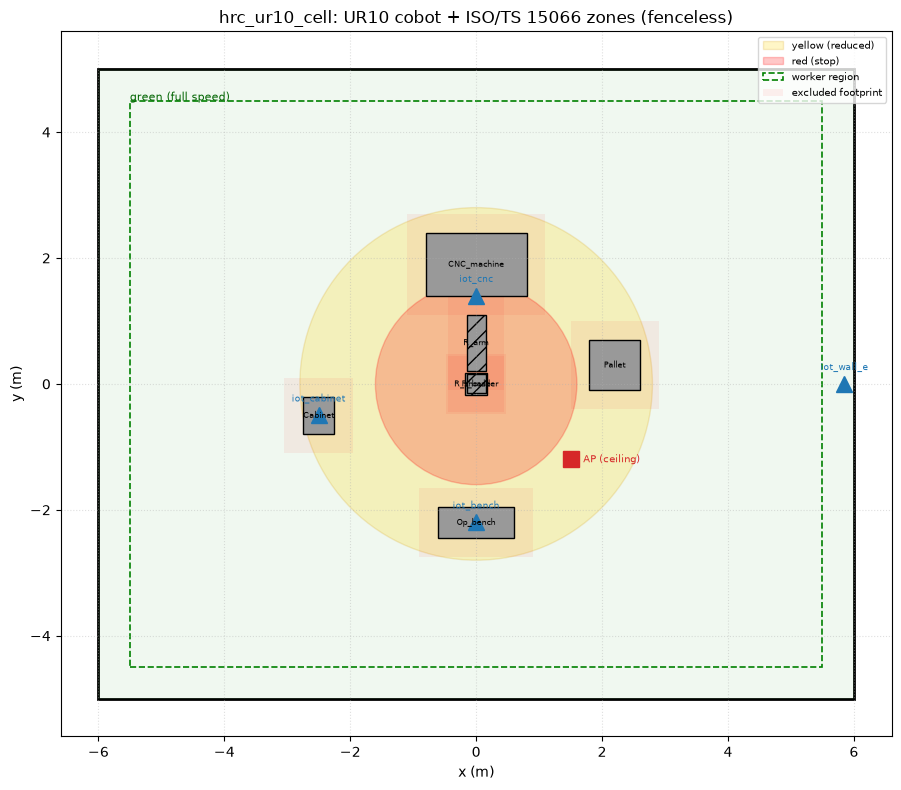

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

cfg = build_sidecar()
fig, ax = plt.subplots(figsize=(9.5, 8))
hx, hy = ROOM_X / 2, ROOM_Y / 2

# bay + green background
ax.add_patch(Rectangle((-hx, -hy), ROOM_X, ROOM_Y, fill=False, edgecolor="black", lw=2))
ax.add_patch(Rectangle((-hx, -hy), ROOM_X, ROOM_Y, facecolor="tab:green", alpha=0.07))

# safety zones (yellow then red on top)
sz = cfg["safety_zones"]
cx0, cy0 = sz["center"]
ax.add_patch(Circle((cx0, cy0), sz["yellow_radius"], facecolor="gold",
                    alpha=0.22, edgecolor="goldenrod", lw=1, label="yellow (reduced)"))
ax.add_patch(Circle((cx0, cy0), sz["red_radius"], facecolor="red",
                    alpha=0.22, edgecolor="red", lw=1, label="red (stop)"))
ax.text(-hx + 0.5, hy - 0.5, "green (full speed)", ha="left", fontsize=8, color="darkgreen")

# worker region + exclusions
wr = cfg["worker_region"]
ax.add_patch(Rectangle((wr["x_min"], wr["y_min"]), wr["x_max"] - wr["x_min"],
                       wr["y_max"] - wr["y_min"], fill=False, edgecolor="green",
                       ls="--", lw=1.2, label="worker region"))
for i, ex in enumerate(wr["exclusions"]):
    ax.add_patch(Rectangle((ex["x_min"], ex["y_min"]), ex["x_max"] - ex["x_min"],
                           ex["y_max"] - ex["y_min"], facecolor="red", alpha=0.06,
                           edgecolor="none", label="excluded footprint" if i == 0 else None))

# objects (robot hatched)
for o in cfg["objects"]:
    sx, sy = o["size"][0], o["size"][1]
    cxx, cyy = o["center"][0], o["center"][1]
    hatch = "//" if o["removable_for_ref"] else None
    ax.add_patch(Rectangle((cxx - sx / 2, cyy - sy / 2), sx, sy, facecolor="0.6",
                           edgecolor="black", hatch=hatch, lw=1.0))
    ax.text(cxx, cyy, o["name"].replace("Robot_", "R_").replace("Operator_", "Op_"),
            ha="center", va="center", fontsize=6.0)

# TX on equipment + ceiling AP
for t in cfg["suggested_tx"]:
    ax.plot(t["pos"][0], t["pos"][1], "^", color="tab:blue", ms=11)
    ax.text(t["pos"][0], t["pos"][1] + 0.22, t["name"], ha="center", fontsize=6.5, color="tab:blue")
ap = cfg["suggested_ap"]["pos"]
ax.plot(ap[0], ap[1], "s", color="tab:red", ms=12)
ax.text(ap[0] + 0.2, ap[1], "AP (ceiling)", va="center", fontsize=7.5, color="tab:red")

ax.set_xlim(-hx - 0.6, hx + 0.6); ax.set_ylim(-hy - 0.6, hy + 0.6)
ax.set_aspect("equal"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title(f"{SCENE_NAME}: UR10 cobot + ISO/TS 15066 zones (fenceless)")
ax.legend(loc="upper right", fontsize=7.5)
ax.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.show()